In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df=pd.read_csv('/content/train.csv')
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [24]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [25]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [26]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Handling the Missing values by the median value for the precise readings Because we know that its a numerical value

In [55]:
df['Age'].fillna(df['Age'].median(), inplace=True)

In [28]:
df['Cabin']=df['Cabin'].fillna(0)

Handling the missing value by the mode Because it contains the categorical values

In [58]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

<ipython-input-58-808ebb813aa0>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [59]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Survival Count

The number of non-survivors is significantly higher than survivors.

Roughly 60% of passengers perished, while 40% survived.

This reflects the tragic nature of the disaster and possibly limited availability of lifeboats and evacuation challenges.

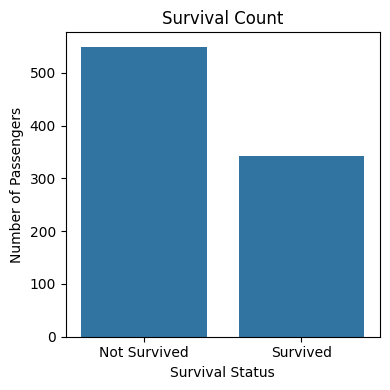

In [61]:
# Plot 1: Survival Count
plt.figure(figsize=(4,4))
sns.countplot(x='Survived', data=df)
plt.title('Survival Count')
plt.xticks([0, 1], ['Not Survived', 'Survived'])
plt.ylabel('Number of Passengers')
plt.xlabel('Survival Status')
plt.tight_layout()
plt.show()

Survival by Gender


Giving the count of passengers survived preffrence by gender

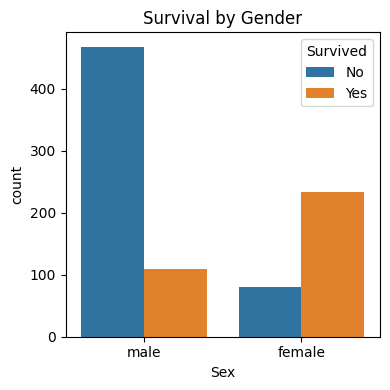

In [62]:
plt.figure(figsize=(4, 4))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival by Gender')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

 Age Distribution


 Here we can see that the graph is giving the normal distribution which means that most of the passengers age is between 20 to 40

 The Titanic had a diverse age range, but most passengers were young adults.

The large spike at age 0 might need further investigation—this could reflect data entry issues or a true high count of infants.

Children and elderly passengers were fewer in number compared to adults.

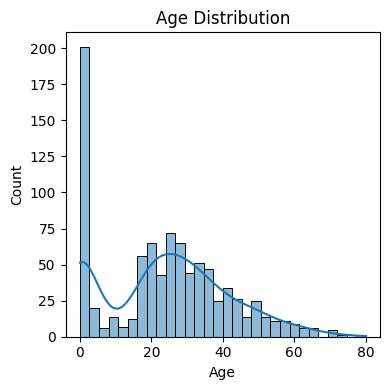

In [63]:
plt.figure(figsize=(4, 4))
sns.histplot(df['Age'].fillna(0), kde=True, bins=30)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


Passenger Class Distribution


Give the number of count  of passengers By the class

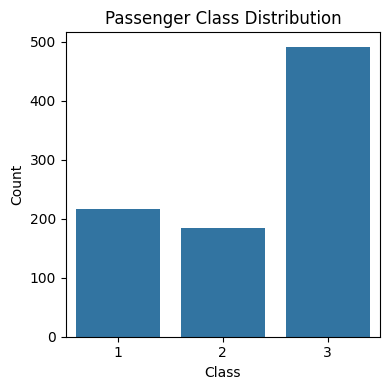

In [64]:
plt.figure(figsize=(4, 4))
sns.countplot(x='Pclass', data=df)
plt.title('Passenger Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


Survival by Passenger Class

Higher-class passengers had better chances of survival, likely due to priority in evacuation and better cabin locations.

Third-class passengers faced the greatest risk, possibly due to limited access to lifeboats and being located in lower parts of the ship.

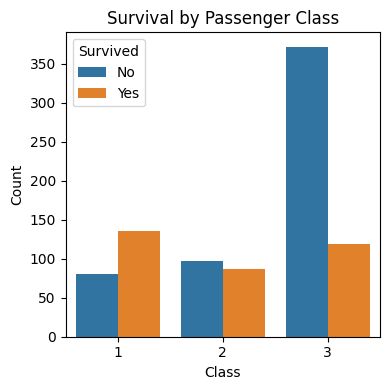

In [65]:
plt.figure(figsize=(4, 4))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival by Passenger Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()


Fare Distribution

Most passengers were likely in lower-class cabins, indicated by the concentration of low fares.

A small number of wealthy passengers paid premium prices, likely for first-class accommodation.

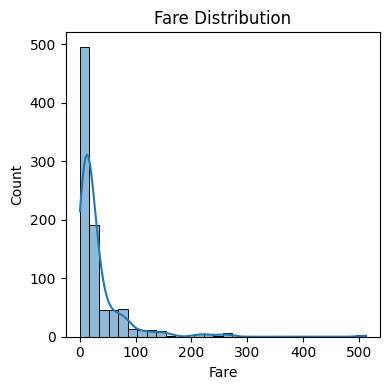

In [66]:
plt.figure(figsize=(4, 4))
sns.histplot(df['Fare'], bins=30, kde=True)
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


Survival by Number of Siblings/Spouses (SibSp)


Passengers traveling alone had the highest count but lower survival rates.

Traveling with 1 sibling or spouse appears to have increased the chances of survival.

Larger family groups (3 or more) had significantly lower survival, possibly due to the difficulty of managing escape with multiple family members

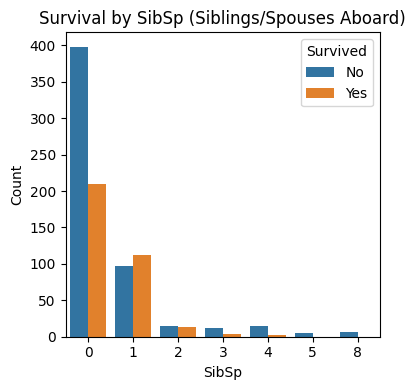

In [67]:
plt.figure(figsize=(4, 4))
sns.countplot(x='SibSp', hue='Survived', data=df)
plt.title('Survival by SibSp (Siblings/Spouses Aboard)')
plt.xlabel('SibSp')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()


Survival by Embarkation Port

Most passengers boarded at Southampton, but it also had the highest number of fatalities.

Cherbourg had a relatively higher survival rate.

Queenstown had the fewest passengers with lower overall survival.

A small number of records have missing embarkation data.

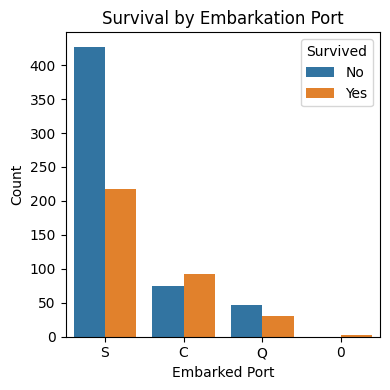

In [68]:
plt.figure(figsize=(4, 4))
sns.countplot(x='Embarked', hue='Survived', data=df)
plt.title('Survival by Embarkation Port')
plt.xlabel('Embarked Port')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()


 Box Plot: Age Distribution by Survival Status

 Give the numbers of passengers who have survived or not are of what age


 The median age is similar for both groups, around 28 years.

Passengers who survived had a slightly narrower age range compared to those who did not survive.

Outliers in the "Survived" group include older passengers (e.g., age above 70).

Children (ages below ~10) appear in both groups, but survival rates for younger passengers may be higher due to evacuation priorities.

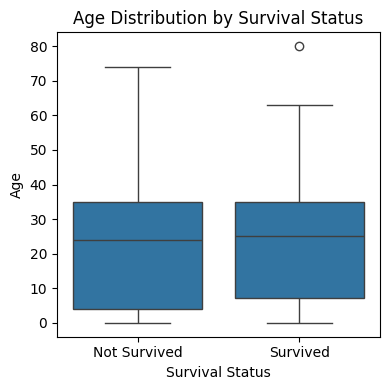

In [69]:
plt.figure(figsize=(4, 4))
sns.boxplot(x='Survived', y='Age', data=df)
plt.title('Age Distribution by Survival Status')
plt.xlabel('Survival Status')
plt.ylabel('Age')
plt.xticks([0, 1], ['Not Survived', 'Survived'])
plt.tight_layout()
plt.show()


Correlation Heatmap



Passengers who paid higher fares were more likely to survive, indicating that class or cabin type played a significant role in survival chances.

Age does not show a strong linear relationship with survival, but younger children seem to have better chances.

Wealthier passengers had access to better resources or evacuation opportunities during the Titanic disaster.

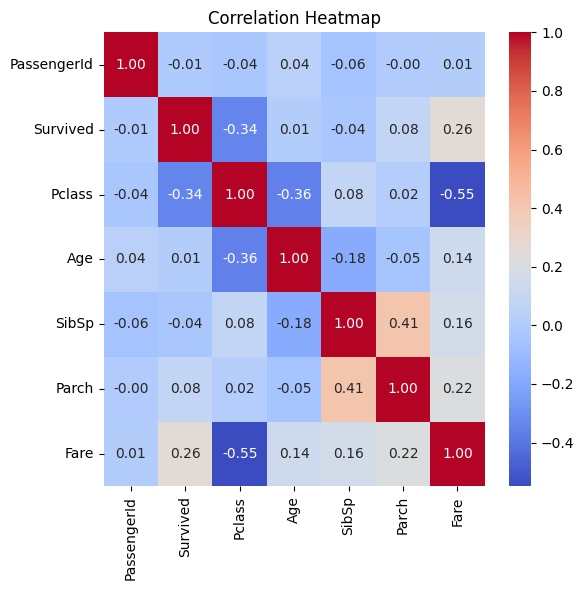

In [49]:
plt.figure(figsize=(6, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()
